a. Implementation: VAE on MNIST using TensorFlow/Keras

b. Implementaton: VAE using PyTorch

In [3]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt 
import numpy as np  

In [9]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar 
    
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1= nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = torch.relu(self.fc1(z))
        x_hat = torch.sigmoid(self.fc2(h))
        return x_hat 

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std 
        x_hat = self.decoder(z)
        return x_hat, mu, logvar 


In [10]:
def loss_function(x, x_hat, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD 

In [12]:
# Hyperparameters
input_dim = 784
hidden_dim =400
latent_dim = 20
lr = 1e-3
batch_size = 128
epochs = 10

# Data Loader 
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Model, optimizer 
vae = VAE(input_dim, hidden_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=lr)

# Training loop
vae.train()
for epoch in range(epochs):
    train_loss = 0
    for x,_ in train_loader:
        x = x.view(-1, input_dim)
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(x)
        loss = loss_function(x, x_hat, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    print(f'Epoch {epoch + 1}, Loss: {train_loss / len(train_loader.dataset)}')

Epoch 1, Loss: 164.4306796549479
Epoch 2, Loss: 121.28284366861979
Epoch 3, Loss: 114.46320486653646
Epoch 4, Loss: 111.50816927083333
Epoch 5, Loss: 109.82566876627604
Epoch 6, Loss: 108.67177034505208
Epoch 7, Loss: 107.84564567057292
Epoch 8, Loss: 107.24818364257813
Epoch 9, Loss: 106.70879599609376
Epoch 10, Loss: 106.29116140950521


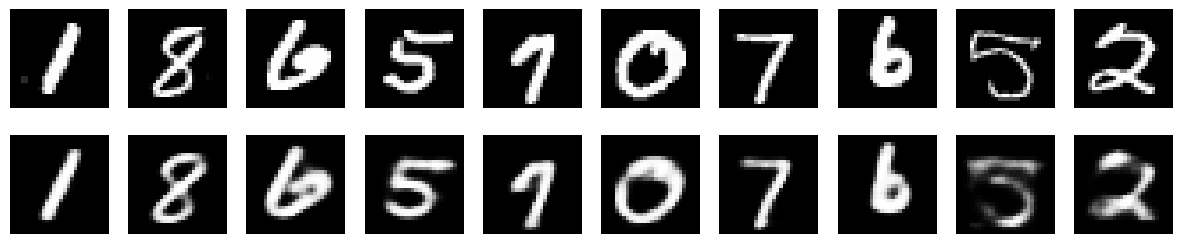

In [13]:
vae.eval()
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, input_dim)
    x_hat, _, _ = vae(x)
    x = x.view(-1, 28, 28)
    x_hat = x_hat.view(-1, 28, 28)

    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axs[0, i].imshow(x[i].cpu().numpy(), cmap='gray')
        axs[1, i].imshow(x_hat[i].cpu().numpy(), cmap='gray')
        axs[0, i].axis('off')
        axs[1, i].axis('off')
    plt.show()



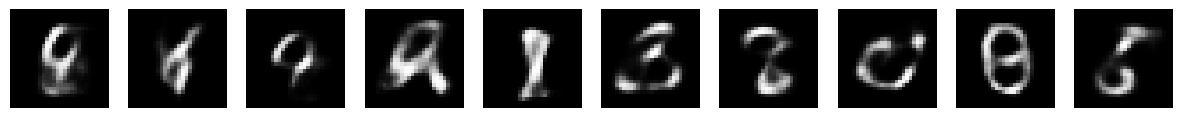

In [15]:
# visualizing generated samples 
with torch.no_grad():
    z = torch.randn(10, latent_dim)
    sample = vae.decoder(z)
    sample = sample.view(-1, 28, 28)

    fig, axs = plt.subplots(1, 10, figsize=(15, 3))
    for i in range(10):
        axs[i].imshow(sample[i].cpu().numpy(), cmap='gray')
        axs[i].axis('off')
    plt.show()


b. GAN code

In [ ]:
import tensorflow as tf
from keras import layers, Model
import numpy as np

(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype('float32') - 127.5) / 127.5 
x_train = x_train.reshape(-1, 784)

\
# Build Generator 
latent_dim = 100
generator = tf.keras.Sequential([
    layers.Input(shape=(latent_dim, )),
    layers.Dense(128, activation='relu'),
    layers.Dense(28*28, activation='tanh') 
])

# Discriminator
discriminator = tf.keras.Sequential([
    layers.Input(shape=(28*28, )),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# Build GAN
discriminator.trainable = False
z = layers.Input(shape=(latent_dim,))
fake = generator(z)
valid = discriminator(fake)
gan = Model(z, valid)
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training
batch_size = 128
epochs = 3
for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    # Generate fake images 
    noise = np.random.randn(batch_size, latent_dim)
    fake_images = generator(noise, training=False)
    
    # Train discriminator
    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))
    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train generator via GAN
    noise = np.random.randn(batch_size, latent_dim)
    g_loss = gan.train_on_batch(noise, real_labels)
    
    # Print progress
    # Print progress
    print(f"Epoch {epoch+1}/{epochs} - D loss: {d_loss[0]:.4f}, "
          f"D accuracy: {d_loss[1]:.4f}, G loss: {g_loss:.4f}")

IndexError: invalid index to scalar variable.

In [23]:
import tensorflow as tf
import numpy as np

# Load and preprocess MNIST (minimal)
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0  # Normalize to [0, 1]
x_train = x_train.reshape(-1, 784)  # Flatten to (batch_size, 784)

# Generator: simple architecture
latent_dim = 50
generator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(latent_dim,)),
    layers.Dense(784, activation='sigmoid')  # Output 28*28=784
])

# Discriminator: simple architecture
discriminator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# GAN: combine models
discriminator.trainable = False
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training loop: minimal
batch_size = 64
for epoch in range(2):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real = x_train[idx]
    noise = np.random.randn(batch_size, latent_dim)
    fake = generator(noise, training=False)
    
    # Train discriminator
    d_loss = 0.5 * (discriminator.train_on_batch(real, np.ones((batch_size, 1))) +
                    discriminator.train_on_batch(fake, np.zeros((batch_size, 1))))
    
    # Train generator
    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))
    
    print(f"Epoch {epoch+1}/2 - D loss: {d_loss:.4f}, G loss: {g_loss:.4f}")

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/2 - D loss: 0.6220, G loss: 0.4145
Epoch 2/2 - D loss: 0.7427, G loss: 0.3836


In [2]:
import tensorflow as tf
import numpy as np
from keras import layers

(x_train, _),_ = tf.keras.datasets.mnist.load_data()

In [7]:
# data preprocessing
x_train = x_train.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28*28)

In [8]:
# Generator 
latent_dim = 50 
generator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(latent_dim, )), 
    layers.Dense(784, activation='sigmoid')
])

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Discriminator 
discriminator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784, )),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Combine Models 
discriminator.trainable = False 
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

In [11]:
# training 
batch_size = 64
for epoch in range(2):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real = x_train[idx] 
    noise = np.random.randn(batch_size, latent_dim)
    fake = generator(noise, training=False)

    # train discriminator 
    d_loss = 0.5 * (discriminator.train_on_batch(real, np.ones((batch_size, 1)))+ discriminator.train_on_batch(fake, np.zeros((batch_size, 1))))

    g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

    print(f"Epoch {epoch+1}/2 - D loss: {d_loss:.4f}, G loss: {g_loss:.4f}")

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/2 - D loss: 0.8022, G loss: 0.8199
Epoch 2/2 - D loss: 0.7712, G loss: 0.7703


In [ ]:
x_train = x_train.astype('float32') / 255.0
x_train = x_train.reshape(-1, 784)

latent_dim = 50
generator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(latent_dim, )),
    layers.Dense(28*28, activation='sigmoid')
])

discriminator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784, )),
    layers.Dense(1, activation='sigmoid')
])
discriminator.compile(optimizer='adam', loss='binary_crossentropy')

discriminator.trainable = False 
gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

batch_size = 64
for epoch in range(2):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real = x_train[idx]
    noise = np.random.randn(batch_size, latent_dim)
    fake = generator(noise, training=False)

    d_loss = 0.5 * (discriminator.train_on_batch(real, np.ones((batch_size, 1))),
                    discriminator.train_on_batch(fake, np.zeros((batch_size, 1))))
    
    g_loss =gan.train_on_batch(noise, np.ones((batch_size, 1)))

    print(epoch, d_loss, g_loss)

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


TypeError: can't multiply sequence by non-int of type 'float'